# 04 · Entrenamiento del predictor del día siguiente

**Requiere TensorFlow** (Google Colab, o local si se resuelve el límite
de "long paths" de Windows — ver README). Este notebook no se ha podido
ejecutar en el entorno de desarrollo de este proyecto; el código está
completo y lee directamente de los `.npz` que deja el notebook 03.

Dos pasos, seleccionando siempre la arquitectura por el ERROR EN
VALIDACIÓN (nunca en test):

1. **Elegir arquitectura** (enunciado, paso 4): con SOLO la ventana real
   disponible para entrenar (sin ningún día sintético), se comparan
   baseline / lineal / densa / CNN / CNN profunda / RNN / RNN profunda —
   misma comparación que `Taller_con_Datos_SP500_promedio.ipynb`, pero
   con nuestros bancos y 2 canales por banco (retorno + volatilidad
   realizada).
2. **Rejilla años de sintéticos × generador**: con la arquitectura
   ganadora, se entrena una versión por cada combinación
   (`SYNTH_DEPTH_YEARS_GRID` años de backfill sintético añadidos) ×
   (generador que rellenó esos años), evaluando siempre en el MISMO test
   real (`REAL_TEST_HOLDOUT_START_DATE` en adelante, jamás visto por
   ningún generador ni en entrenamiento).

**Sobre las fechas** (ver `src/config.py`): la ventana real de
`REAL_INTRADAY_YEARS` (~2 años) se reparte en train/val/test — val y test
se comen la mitad, así que lo que queda para entrenar "solo con reales"
es solo ~1 año (`synth_years=0`). A partir de ahí, `synth_years` cuenta
hacia atrás desde `REAL_INTRADAY_START_DATE` cuánta historia con
volatilidad SINTÉTICA se añade — el final del entrenamiento
(`VAL_START_DATE`) es siempre el mismo, no cambia con la profundidad.

**Sobre la métrica — MAE como loss, no solo como número final**: los
notebooks de clase compilan con `loss='mse'` y solo reportan MAE después
de entrenar. Pero la propia diapositiva de teoría del taller ("REAL
PROBLEM", `2026_Taller_Generativos.pdf` pág. 11-12) dice explícitamente
**"Learning: minimize MAE"** para el problema real que motiva todo el
taller — y sus resultados (pág. 27-28) se reportan en las unidades del
target (Kelvin), la ventaja práctica de MAE frente a MSE (que está en
unidades al cuadrado, no interpretables directamente). Nuestro target
(retorno diario) es igual de heavy-tailed que un problema físico con
outliers — lo vimos nosotros mismos en el notebook 02 (la Gaussiana no
reproduce el pico leptocúrtico de los datos reales) — así que entrenar
con MSE dejaría que los pocos días de retorno extremo dominen el
gradiente. Por eso aquí se entrena con `loss='mae'` (parámetro de
`src/modelos.py`, no hay que tocar el fichero — ver `LOSS_FUNCTION` más
abajo), más fiel al principio de la teoría del taller que a la
implementación literal del notebook de juguete. Se siguen reportando
MAE, MSE y precisión direccional para cada modelo.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config, modelos, plotting as pl, train_utils as tu

# EPOCHS_* son ahora un TECHO, no el nº de epochs que realmente se entrena:
# tanto run_architecture_comparison como run_depth_grid paran antes via
# EarlyStopping (patience=15 sobre val_loss, se queda con los mejores
# pesos vistos) — entrenar dataset de 250 filas y de 7300 filas el mismo
# nº fijo de epochs no tiene sentido (el pequeno sobreajusta mucho antes;
# el grande ni converge), y desperdicia tiempo en los que ya convergieron.
# Poner EARLY_STOPPING_PATIENCE=None reproduce el comportamiento literal
# de los notebooks de clase (epochs fijas, sin parada temprana).
EPOCHS_ARQUITECTURA = 200
EPOCHS_REJILLA = 300
BATCH_SIZE = 64
EARLY_STOPPING_PATIENCE = 15
LOSS_FUNCTION = "mae"  # ver justificacion arriba; cambiar a "mse" reproduce el notebook de clase literal

## 1. Cargar los 4 datasets de 30 años (notebook 03)

In [2]:
datasets_by_generator = {}
for name in ["noise", "gaussian", "rbig", "gan"]:
    path = config.INTERIM_DIR / f"dataset_{name}.npz"
    if not path.exists():
        continue
    npz = np.load(path, allow_pickle=True)
    idx = pd.DatetimeIndex(npz["idx"])
    datasets_by_generator[name] = (npz["X"], npz["Y"], idx, npz["is_synthetic"])
    print(f"{name}: X {npz['X'].shape}  Y {npz['Y'].shape}")

N_CHANNELS = datasets_by_generator[next(iter(datasets_by_generator))][0].shape[-1]  # 2 * N_PREDICTOR_TICKERS
assert N_CHANNELS == 2 * config.N_PREDICTOR_TICKERS

noise: X (7326, 60, 50)  Y (7326, 25)


gaussian: X (7326, 60, 50)  Y (7326, 25)


rbig: X (7326, 60, 50)  Y (7326, 25)


gan: X (7326, 60, 50)  Y (7326, 25)


## 2. Separar validación y test (reales, jamás usados por los generadores)

In [3]:
def val_test_split(X, Y, idx):
    val_mask = (idx >= pd.Timestamp(config.VAL_START_DATE)) & (idx < pd.Timestamp(config.REAL_TEST_HOLDOUT_START_DATE))
    test_mask = idx >= pd.Timestamp(config.REAL_TEST_HOLDOUT_START_DATE)
    return (X[val_mask], Y[val_mask]), (X[test_mask], Y[test_mask])

ref_name = next(iter(datasets_by_generator))
(X_val, Y_val), (X_test, Y_test) = val_test_split(*datasets_by_generator[ref_name][:3])
print(f"val: {X_val.shape}   test: {X_test.shape}")

val: (126, 60, 50)   test: (122, 60, 50)


## 3. Elegir arquitectura, usando SOLO la ventana real disponible

`synth_years=0`: ni un solo día con volatilidad sintética todavía (ver
`train_utils.slice_by_depth`) — solo el ~1 año real que queda entre
`REAL_INTRADAY_START_DATE` y `VAL_START_DATE`.

In [4]:
X_full, Y_full, idx_full, is_synth_full = datasets_by_generator[ref_name]
X_train_arch, Y_train_arch, _, _ = tu.slice_by_depth(
    X_full, Y_full, idx_full, synth_years=0,
    train_end=config.VAL_START_DATE, synth_anchor=config.REAL_INTRADAY_START_DATE,
    is_synthetic=is_synth_full,
)
print("train (arquitectura, solo reales):", X_train_arch.shape)

output_dim = config.N_PREDICTOR_TICKERS
window_x = config.WINDOW_X_DAYS

architectures = {
    "baseline": lambda: modelos.build_predictor_baseline(output_dim=output_dim),
    "linear": lambda: modelos.build_predictor_linear(),
    "dense": lambda: modelos.build_predictor_dense(
        window_x, N_CHANNELS, output_dim, hidden_units=(128, 64), loss=LOSS_FUNCTION
    ),
    "cnn_1bloque": lambda: modelos.build_predictor_cnn(
        window_x, N_CHANNELS, output_dim, conv_filters=(64,), loss=LOSS_FUNCTION
    ),
    "cnn_3bloques": lambda: modelos.build_predictor_cnn(
        window_x, N_CHANNELS, output_dim, conv_filters=(64, 128, 128), loss=LOSS_FUNCTION
    ),
    "rnn_1capa": lambda: modelos.build_predictor_rnn(
        window_x, N_CHANNELS, output_dim, lstm_units=(64,), loss=LOSS_FUNCTION
    ),
    "rnn_2capas": lambda: modelos.build_predictor_rnn(
        window_x, N_CHANNELS, output_dim, lstm_units=(64, 128), loss=LOSS_FUNCTION
    ),
}

arch_results, arch_histories = tu.run_architecture_comparison(
    architectures, X_train_arch, Y_train_arch, X_val, Y_val, X_test, Y_test,
    epochs=EPOCHS_ARQUITECTURA, batch_size=BATCH_SIZE, verbose=0,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
)
arch_results.to_csv(config.TABLES_DIR / "04_comparacion_arquitecturas.csv")
arch_results.sort_values("mae")

train (arquitectura, solo reales): (252, 60, 50)


.../site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


.../site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


,fit_seconds,mse,mae,directional_accuracy
model,,,,
cnn_3bloques,2.844592,0.000251,0.011789,0.515410
rnn_1capa,4.474647,0.000252,0.011807,0.504918
cnn_1bloque,2.032166,0.000251,0.011808,0.511475
rnn_2capas,8.356967,0.000252,0.011816,0.498689
dense,2.007252,0.000256,0.011950,0.508525
linear,0.090545,0.000411,0.015857,0.478033
baseline,0.000000,0.000512,0.017367,0.476721


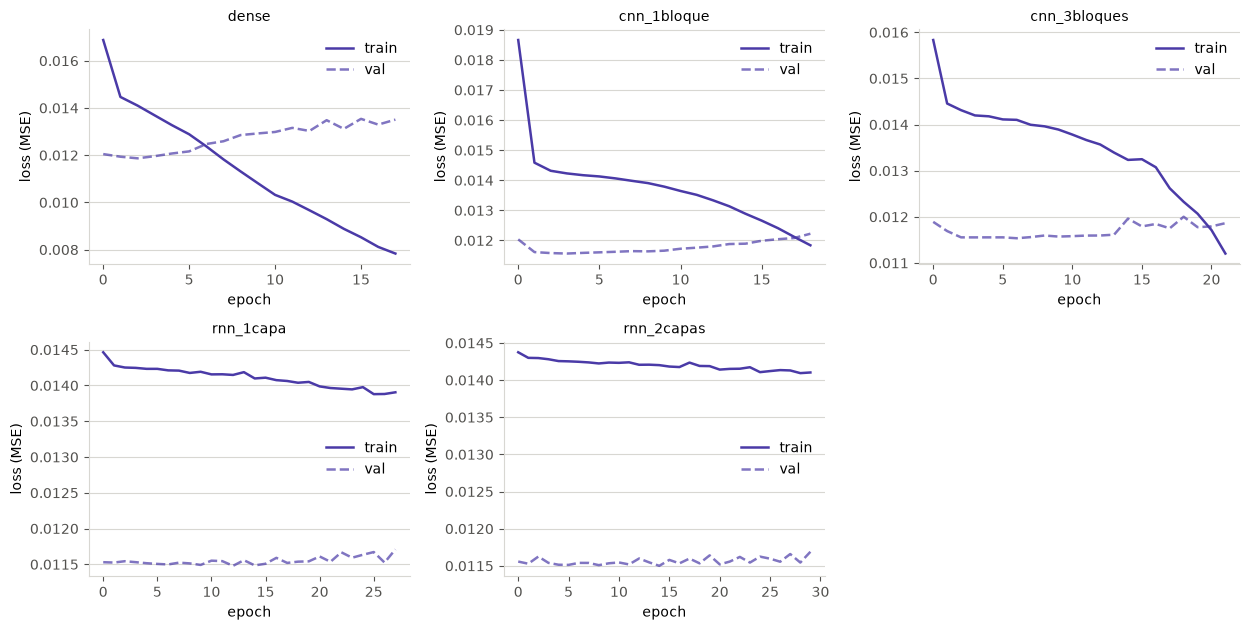

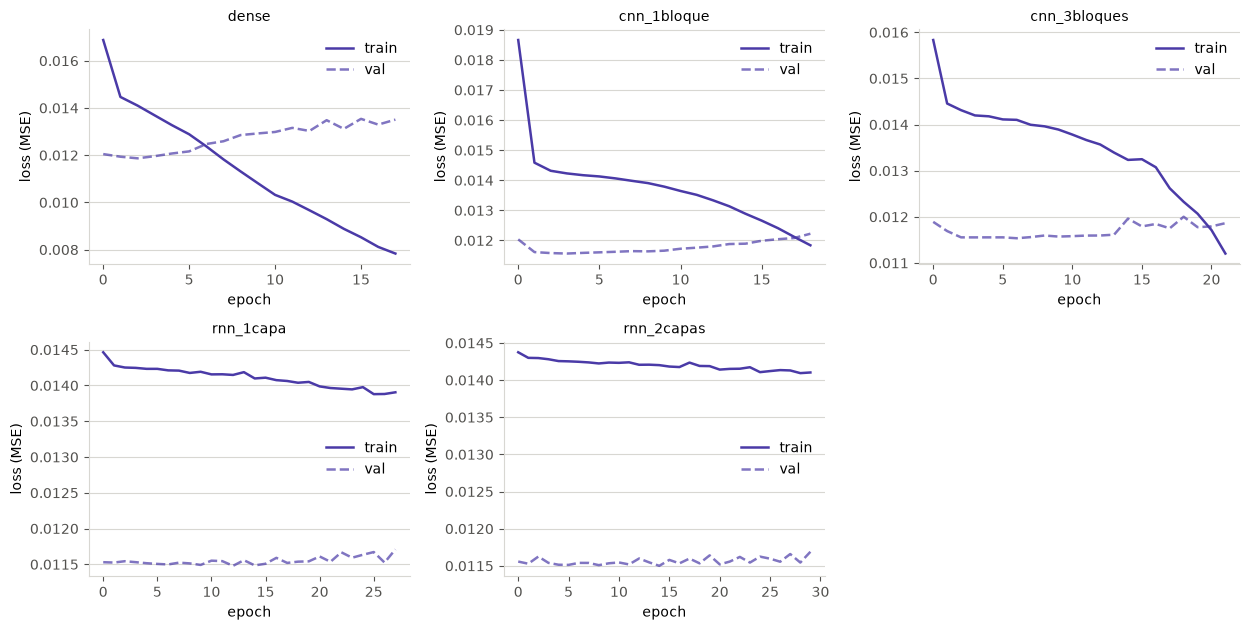

In [5]:
fig = pl.plot_loss_grid(arch_histories, ncols=3)
pl.savefig(fig, "04_loss_curvas_arquitecturas")
fig

Se elige la arquitectura con menor MAE en **validación** (no en test:
el test se reserva íntegro para la comparación de generadores del
siguiente paso). `cnn_3bloques` reproduce `cnn_model_2` de
`Taller_GANs.ipynb`, la arquitectura con la que la propia clase compara
GAN/RBIG — es la elección por defecto salvo que la validación diga
claramente lo contrario.

In [6]:
ARQUITECTURA_GANADORA = arch_results["mae"].idxmin()
mejor_direccional = arch_results["directional_accuracy"].idxmax()
print("Arquitectura elegida (menor MAE):", ARQUITECTURA_GANADORA)
if mejor_direccional != ARQUITECTURA_GANADORA:
    print(
        f"[AVISO] '{mejor_direccional}' tiene mejor precisión direccional "
        f"({arch_results.loc[mejor_direccional, 'directional_accuracy']:.3f} vs "
        f"{arch_results.loc[ARQUITECTURA_GANADORA, 'directional_accuracy']:.3f}) aunque peor MAE — "
        "el criterio de selección (MAE, ver justificación de la métrica arriba) no siempre "
        "coincide con el de mejor acierto de signo. Merece la pena citar ambos en la presentación."
    )


def build_final_model():
    if ARQUITECTURA_GANADORA == "cnn_1bloque":
        return modelos.build_predictor_cnn(window_x, N_CHANNELS, output_dim, conv_filters=(64,), loss=LOSS_FUNCTION)
    if ARQUITECTURA_GANADORA == "cnn_3bloques":
        return modelos.build_predictor_cnn(
            window_x, N_CHANNELS, output_dim, conv_filters=(64, 128, 128), loss=LOSS_FUNCTION
        )
    if ARQUITECTURA_GANADORA == "rnn_1capa":
        return modelos.build_predictor_rnn(window_x, N_CHANNELS, output_dim, lstm_units=(64,), loss=LOSS_FUNCTION)
    if ARQUITECTURA_GANADORA == "rnn_2capas":
        return modelos.build_predictor_rnn(
            window_x, N_CHANNELS, output_dim, lstm_units=(64, 128), loss=LOSS_FUNCTION
        )
    if ARQUITECTURA_GANADORA == "dense":
        return modelos.build_predictor_dense(
            window_x, N_CHANNELS, output_dim, hidden_units=(128, 64), loss=LOSS_FUNCTION
        )
    raise ValueError(f"Arquitectura no keras seleccionada ({ARQUITECTURA_GANADORA}); revisar manualmente.")

Arquitectura elegida (menor MAE): cnn_3bloques


## 4. Rejilla años de backfill sintético × generador

`synth_years=0` es idéntico para los 4 (sin sintéticos: fila
`solo_reales`, una sola vez); a partir de ahí cada generador aporta su
propio backfill y diverge. Se calcula también el desglose MAE/MSE/
precisión direccional POR BANCO (`ticker_names`), igual que la
comparación final de `Taller_con_Datos_SP500_promedio.ipynb`: una MAE
pooleada sobre los 25 bancos queda dominada por los de mayor volatilidad
(ver notebook 01, GBCI ~1.6x más volátil que JPM).

In [7]:
results, histories, per_ticker = tu.run_depth_grid(
    build_final_model, datasets_by_generator, X_val, Y_val, X_test, Y_test,
    synth_years_grid=config.SYNTH_DEPTH_YEARS_GRID, train_end=config.VAL_START_DATE,
    synth_anchor=config.REAL_INTRADAY_START_DATE,
    epochs=EPOCHS_REJILLA, batch_size=BATCH_SIZE, verbose=0,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    ticker_names=config.PREDICTOR_TICKERS,
)
results.to_csv(config.TABLES_DIR / "04_resultados_rejilla_profundidad.csv")
results.sort_values(["generator", "synth_years"])

.../site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


...

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


,generator,synth_years,n_train,pct_synth,mse,mae,directional_accuracy
4,gan,7,2013,0.874814,0.000251,0.011770,0.515082
8,gan,14,3774,0.933227,0.000250,0.011754,0.529180
12,gan,21,5537,0.954488,0.000249,0.011796,0.517377
16,gan,28,7078,0.964397,0.000250,0.011762,0.520000
2,gaussian,7,2013,0.874814,0.000250,0.011794,0.502295
6,gaussian,14,3774,0.933227,0.000250,0.011774,0.518689
10,gaussian,21,5537,0.954488,0.000250,0.011757,0.520000
14,gaussian,28,7078,0.964397,0.000250,0.011785,0.499672
1,noise,7,2013,0.874814,0.000250,0.011771,0.520984
5,noise,14,3774,0.933227,0.000251,0.011768,0.525246


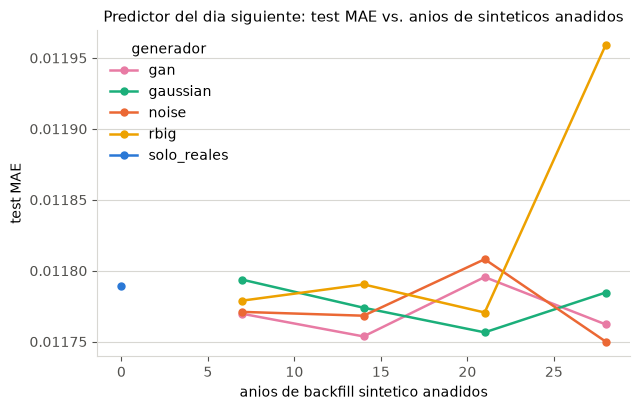

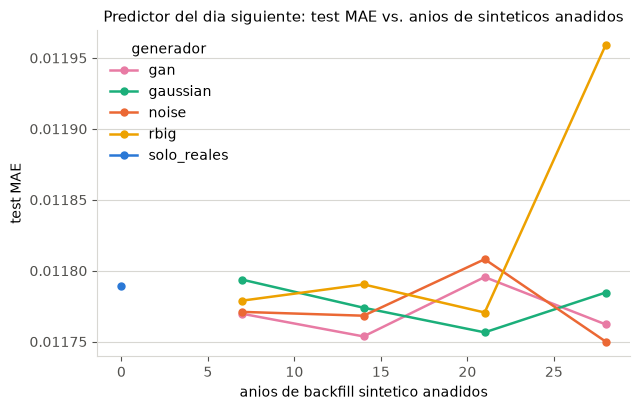

In [8]:
fig = pl.plot_depth_grid_results(results, metric="mae")
pl.savefig(fig, "04_mae_vs_profundidad")
fig

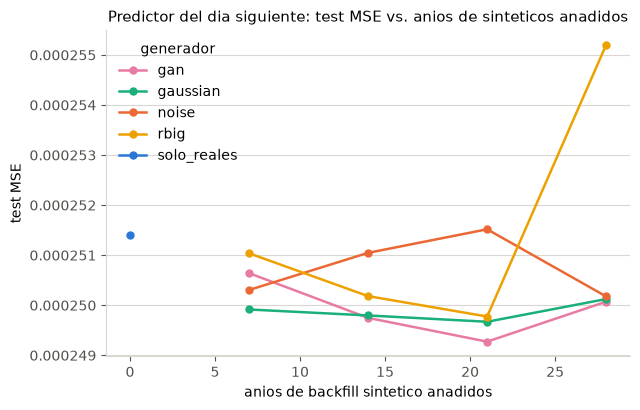

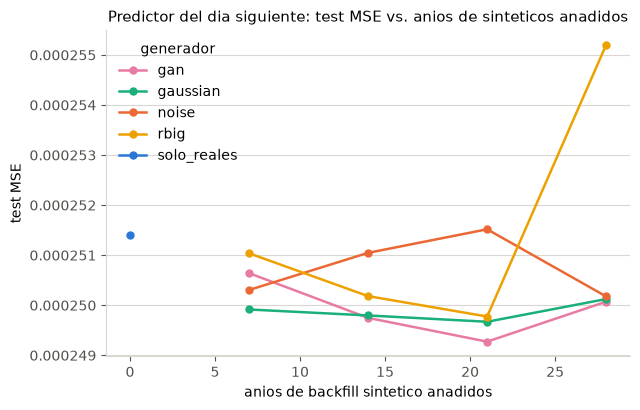

In [9]:
fig = pl.plot_depth_grid_results(results, metric="mse")
pl.savefig(fig, "04_mse_vs_profundidad")
fig

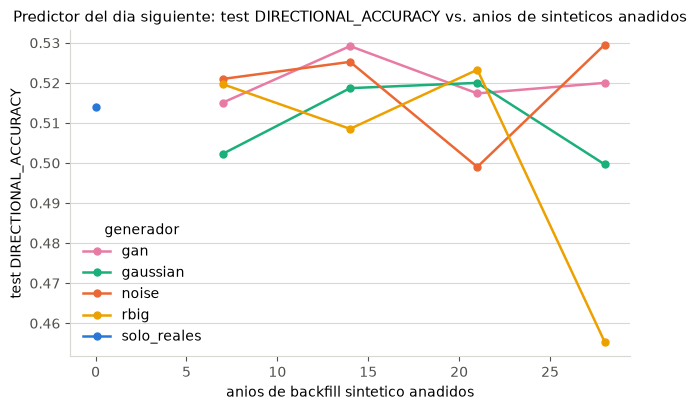

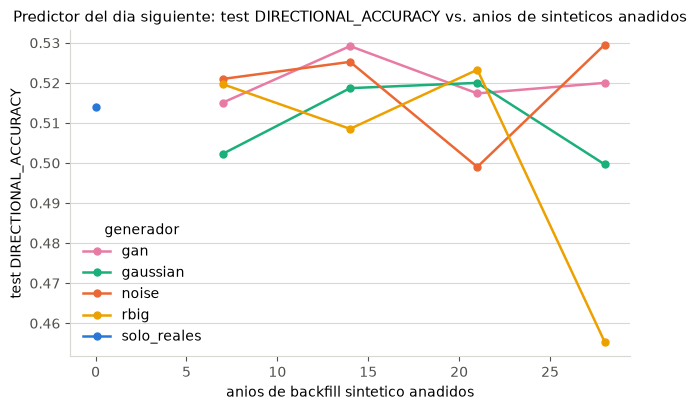

In [10]:
fig = pl.plot_depth_grid_results(results, metric="directional_accuracy")
pl.savefig(fig, "04_precision_direccional_vs_profundidad")
fig

## 5. Desglose por banco a máxima profundidad sintética

Gráfico de barras agrupado MAE por banco y generador (misma idea que el
bloque final de `Taller_con_Datos_SP500_promedio.ipynb`), en el punto de
mayor profundidad de la rejilla.

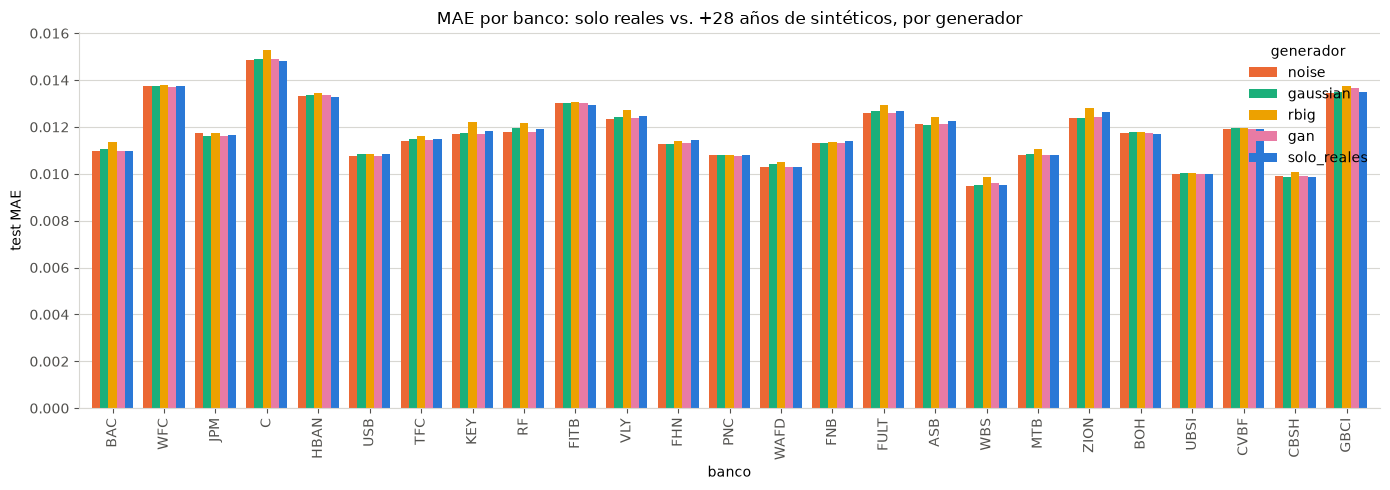

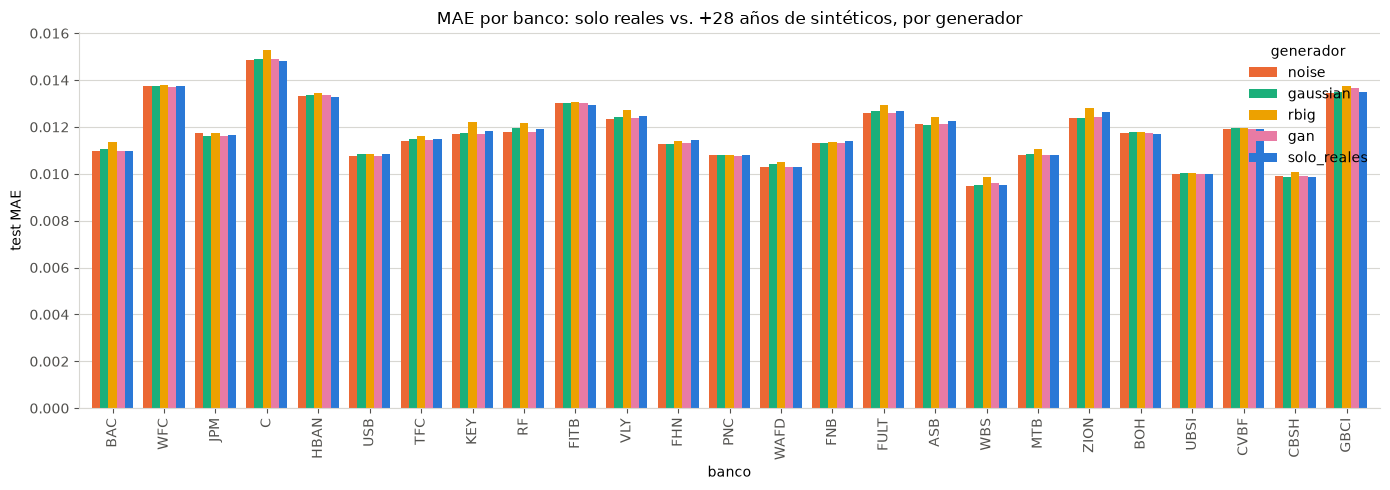

In [11]:
synth_years_max = config.SYNTH_DEPTH_YEARS_GRID[-1]
per_ticker_final = {
    gen_name: df for (gen_name, sy), df in per_ticker.items() if sy == synth_years_max
}
per_ticker_final["solo_reales"] = per_ticker[("solo_reales", config.SYNTH_DEPTH_YEARS_GRID[0])]

per_ticker_table = pd.concat(
    {name: df["mae"] for name, df in per_ticker_final.items()}, axis=1
)
per_ticker_table.to_csv(config.TABLES_DIR / "04_mae_por_banco.csv")

fig, ax = plt.subplots(figsize=(14, 5))
per_ticker_table.plot(
    kind="bar", ax=ax,
    color=[pl.color_for(c) for c in per_ticker_table.columns],
    width=0.8,
)
ax.set_ylabel("test MAE")
ax.set_xlabel("banco")
ax.set_title(f"MAE por banco: solo reales vs. +{synth_years_max} años de sintéticos, por generador")
ax.legend(frameon=False, title="generador")
pl.style_axes(ax)
fig.tight_layout()
pl.savefig(fig, "04_mae_por_banco")
fig

## 6. Curvas de loss: `solo_reales` (synth_years=0) vs. historia completa
   (synth_years=28), por generador

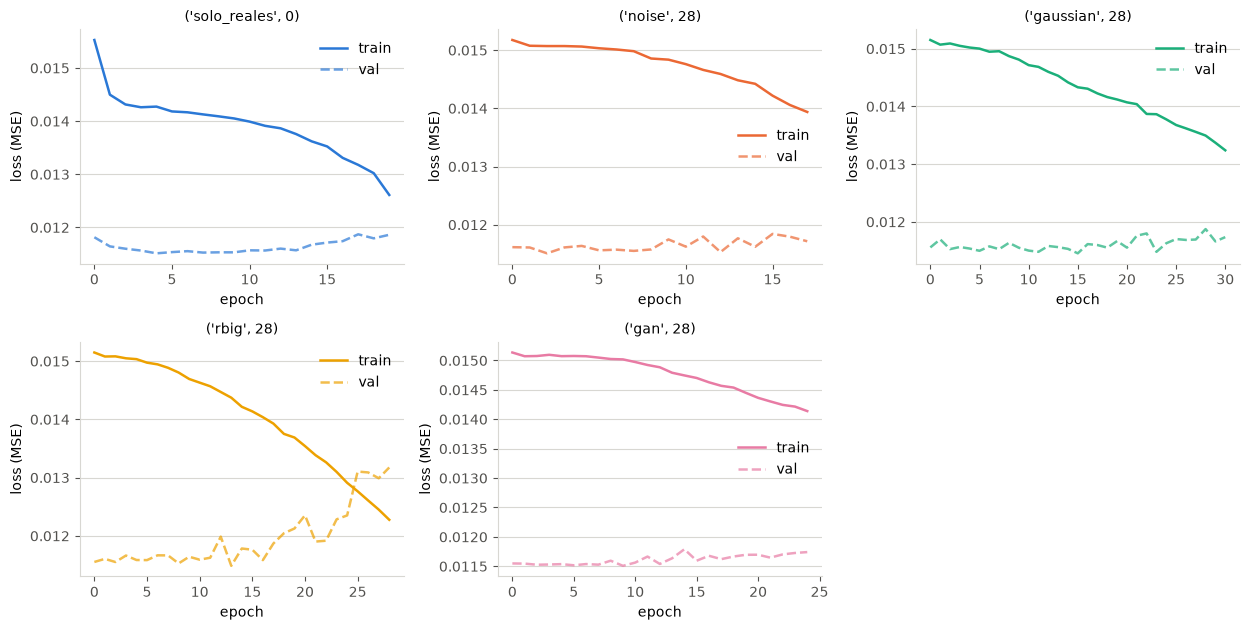

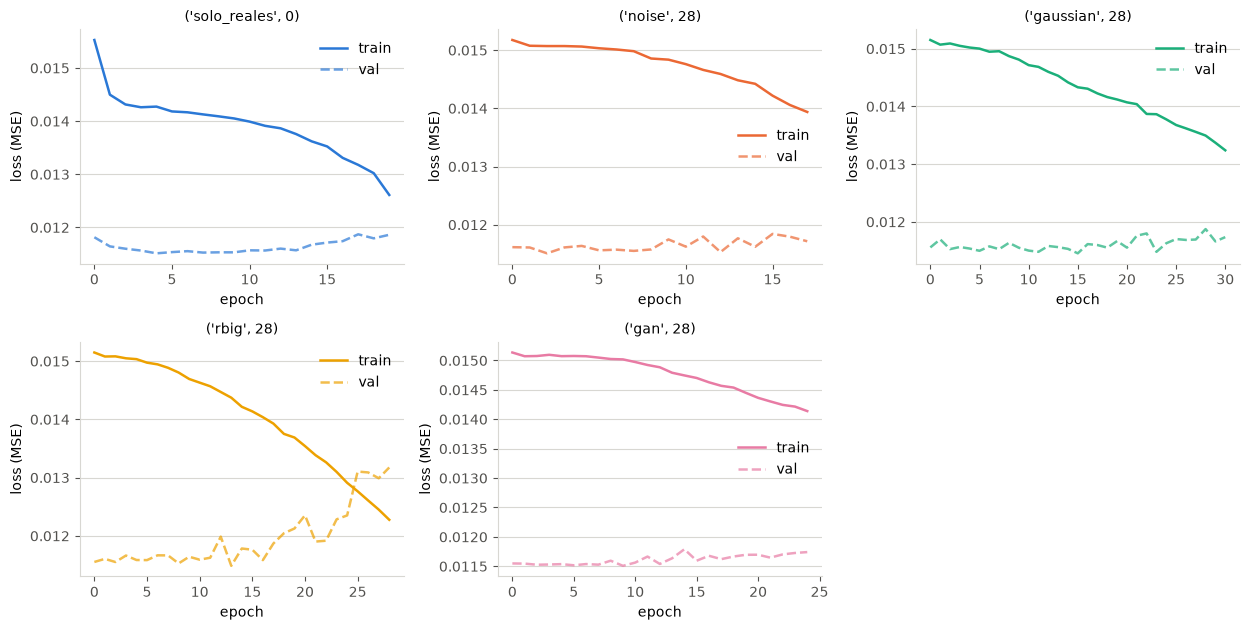

In [12]:
subset_histories = {
    k: v for k, v in histories.items()
    if k[1] in (config.SYNTH_DEPTH_YEARS_GRID[0], config.SYNTH_DEPTH_YEARS_GRID[-1])
}
fig = pl.plot_loss_grid(subset_histories, ncols=3)
pl.savefig(fig, "04_loss_curvas_rejilla")
fig

## 7. Guardar resultados consolidados (`datos/interim/`, gitignored)

El notebook 05 solo lee estos CSV/tablas — no vuelve a entrenar nada.

In [13]:
results.to_pickle(config.INTERIM_DIR / "resultados_finales.pkl")
per_ticker_table.to_pickle(config.INTERIM_DIR / "resultados_por_banco.pkl")
print("Listo. Tabla completa en reports/tables/04_resultados_rejilla_profundidad.csv")

Listo. Tabla completa en reports/tables/04_resultados_rejilla_profundidad.csv
